In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load & Merge



In [2]:
matches_df=pd.read_csv('matches.csv')
deliveries_df=pd.read_csv('deliveries.csv')
df=pd.merge(matches_df,deliveries_df,right_on='match_id',left_on='id',how='outer')
df

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150455,636,2016,Bangalore,2016-05-29,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,bat,normal,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
150456,636,2016,Bangalore,2016-05-29,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,bat,normal,0,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
150457,636,2016,Bangalore,2016-05-29,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,bat,normal,0,...,0,1,0,0,0,1,1,NaN,NaN,NaN
150458,636,2016,Bangalore,2016-05-29,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,bat,normal,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN


In [3]:
print('Shape of Dataset',df.shape)
print('\nColumn Names:',df.columns.tolist())
print('\n===Data Types of each Column===')
print(df.dtypes)
print('Seasons Covered:',df['season'].value_counts().index.tolist())


Shape of Dataset (150460, 39)

Column Names: ['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3', 'match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed', 'dismissal_kind', 'fielder']

===Data Types of each Column===
id                    int64
season                int64
city                    str
date                    str
team1                   str
team2                   str
toss_winner             str
toss_decision           str
result                  str
dl_applied            int64
winner                  str
win_by_runs           int64
win_by_wickets        int64
player_of_match         str
venue                   str
umpi

### Interpretation

The match dataset gives overall match details, while the delivery dataset gives ball-by-ball details.  
After merging, each delivery row also contains match information such as season, venue, winner, toss decision, and date.  
This merged dataset is useful for deeper analysis because both ball-level and match-level information are available together.

## 2. Handle Missing Data



In [4]:
print('=== Missing Values in each Column ===')
print(df.isnull().sum())
matches_df['player_of_match']=matches_df['player_of_match'].fillna('Unknown')
print(matches_df.isnull().sum())
deliveries_df['dismissal_kind']=deliveries_df['dismissal_kind'].fillna('not out')
deliveries_df

=== Missing Values in each Column ===
id                       0
season                   0
city                  1700
date                     0
team1                    0
team2                    0
toss_winner              0
toss_decision            0
result                   0
dl_applied               0
winner                 321
win_by_runs              0
win_by_wickets           0
player_of_match        321
venue                    0
umpire1                248
umpire2                248
umpire3             150460
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs       

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,not out,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,not out,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,not out,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,not out,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,not out,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150455,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,2,0,2,NaN,not out,NaN
150456,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
150457,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,B Kumar,0,...,0,1,0,0,0,1,1,NaN,not out,NaN
150458,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,B Kumar,0,...,0,0,0,0,1,0,1,NaN,not out,NaN


### Interpretation

The `city` column is important for venue analysis, so the missing values are not dropped.  
The `player_of_match` values are also kept by replacing missing entries with a meaningful label.  
For `dismissal_kind`, missing values naturally mean no wicket fell on that delivery, so replacing them with `"not out"` is the correct treatment.

## 3. Feature Engineering

In [5]:
deliveries_df['total_runs']=deliveries_df['batsman_runs']+deliveries_df['extra_runs']
batsman_runs_arr=np.array(deliveries_df['batsman_runs'])
deliveries_df['is_boundary']=np.where(batsman_runs_arr>=4,'boundary','non-boundary')
over_arr=np.array(deliveries_df['over'])
deliveries_df['over_phase']=np.where(over_arr<=6,'Powerplay',np.where(over_arr<=15,'Middle','Death'))
print(deliveries_df)

matches_df['date'] = pd.to_datetime(matches_df['date'])
matches_df['year'] = matches_df['date'].dt.year
matches_df['month'] = matches_df['date'].dt.month
print(matches_df)

        match_id  inning                 batting_team  \
0              1       1          Sunrisers Hyderabad   
1              1       1          Sunrisers Hyderabad   
2              1       1          Sunrisers Hyderabad   
3              1       1          Sunrisers Hyderabad   
4              1       1          Sunrisers Hyderabad   
...          ...     ...                          ...   
150455       636       2  Royal Challengers Bangalore   
150456       636       2  Royal Challengers Bangalore   
150457       636       2  Royal Challengers Bangalore   
150458       636       2  Royal Challengers Bangalore   
150459       636       2  Royal Challengers Bangalore   

                       bowling_team  over  ball        batsman    non_striker  \
0       Royal Challengers Bangalore     1     1      DA Warner       S Dhawan   
1       Royal Challengers Bangalore     1     2      DA Warner       S Dhawan   
2       Royal Challengers Bangalore     1     3      DA Warner       S D

### Interpretation

The new columns make the dataset more useful for cricket analysis.  
For example, `over_phase` allows comparison of scoring patterns in powerplay, middle, and death overs.  
The `year` and `month` columns help in seasonal trend analysis.

## 4. Aggregations & Summary Statistics

In [6]:
print(deliveries_df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(5))

deliveries_df["bowler_runs_conceded"] = (deliveries_df["total_runs"]- deliveries_df["bye_runs"]- deliveries_df["legbye_runs"]- deliveries_df["penalty_runs"])
deliveries_df["legal_ball"] = np.where((deliveries_df["wide_runs"] == 0) & (deliveries_df["noball_runs"] == 0),1,0)
bowler_summary = (deliveries_df.groupby("bowler").agg(runs_conceded=("bowler_runs_conceded", "sum"),balls=("legal_ball", "sum")).reset_index())
bowler_summary_500 = bowler_summary[bowler_summary["balls"] >= 500].copy()
bowler_summary_500["overs"] = bowler_summary_500["balls"] / 6
bowler_summary_500["economy_rate"] = np.round(bowler_summary_500["runs_conceded"].to_numpy()/ bowler_summary_500["overs"].to_numpy(),2)
best_economy_bowlers = bowler_summary_500.sort_values("economy_rate").head(10)
print('\n',best_economy_bowlers)

teams_by_season = pd.concat([matches_df[["season", "team1"]].rename(columns={"team1": "team"}),matches_df[["season", "team2"]].rename(columns={"team2": "team"})])
matches_played = (teams_by_season.groupby(["season", "team"]).size().reset_index(name="matches_played"))
wins = (matches_df.dropna(subset=["winner"]).groupby(["season", "winner"]).size().reset_index(name="wins").rename(columns={"winner": "team"}))
win_percentage = matches_played.merge(wins,on=["season", "team"],how="left")
win_percentage["wins"] = win_percentage["wins"].fillna(0).astype(int)
win_percentage["win_percentage"] = np.round((win_percentage["wins"] / win_percentage["matches_played"]) * 100,2)
best_team_each_season = (win_percentage.sort_values(["season", "win_percentage"], ascending=[True, False]).groupby("season").head(1).reset_index(drop=True))
print('\n',best_team_each_season)

batsman
SK Raina     4548
V Kohli      4423
RG Sharma    4207
G Gambhir    4132
DA Warner    4014
Name: batsman_runs, dtype: int64

               bowler  runs_conceded  balls       overs  economy_rate
300        SP Narine           2042   1931  321.833333          6.34
234         R Ashwin           2499   2290  381.666667          6.55
4           A Kumble           1058    965  160.833333          6.58
181   M Muralitharan           1706   1528  254.666667          6.70
103         DW Steyn           2321   2064  344.000000          6.75
96        DL Vettori            878    777  129.500000          6.78
294       SL Malinga           2927   2558  426.333333          6.87
126          J Botha            800    694  115.666667          6.92
117  Harbhajan Singh           3385   2919  486.500000          6.96
241         R Sharma           1086    928  154.666667          7.02

    season                   team  matches_played  wins  win_percentage
0    2008       Rajasthan Royals   

### Interpretation

The run aggregation identifies the most consistent and successful batsmen in the dataset.  
Economy rate helps identify bowlers who controlled runs effectively over a large sample size.  
Season-wise win percentage shows which team dominated each IPL season.

## 5. Toss Impact on Match Outcome

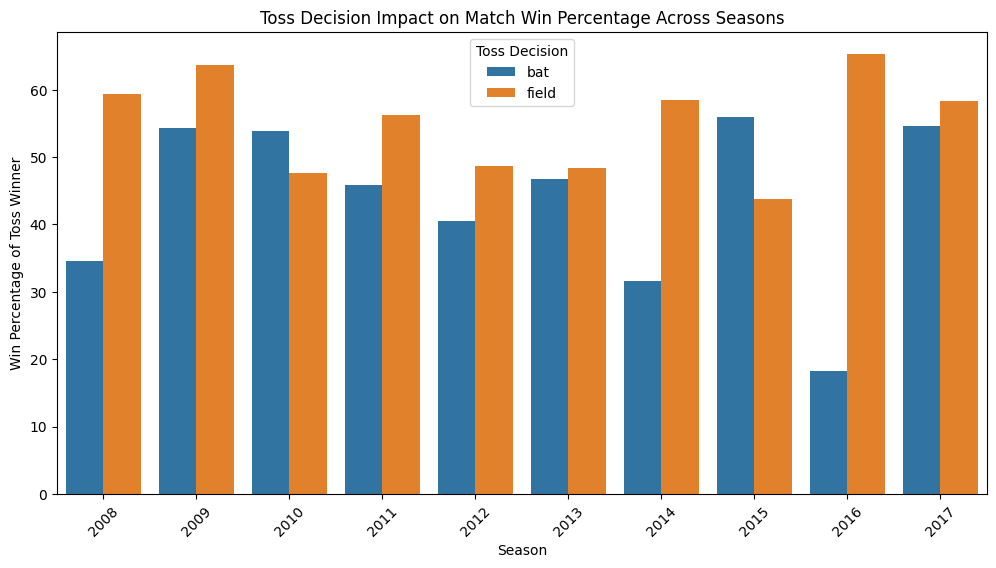

toss_decision
bat      45.59
field    55.68
Name: toss_winner_won_match, dtype: float64

In [7]:
toss_df = matches_df.dropna(subset=["winner"]).copy()
toss_df["toss_winner_won_match"] = toss_df["toss_winner"] == toss_df["winner"]
toss_impact = (toss_df.groupby(["season", "toss_decision"])["toss_winner_won_match"].mean().mul(100).reset_index(name="win_percentage"))
plt.figure(figsize=(12, 6))
sns.barplot(data=toss_impact,x="season",y="win_percentage",hue="toss_decision")
plt.title("Toss Decision Impact on Match Win Percentage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Win Percentage of Toss Winner")
plt.legend(title="Toss Decision")
plt.xticks(rotation=45)
plt.show()
overall_toss_impact = (toss_df.groupby("toss_decision")["toss_winner_won_match"].mean().mul(100).round(2))
overall_toss_impact

### Interpretation

Across the full dataset, teams choosing to field after winning the toss have a higher winning percentage than teams choosing to bat first.  
However, the advantage is not perfectly consistent in every season, so toss decision alone cannot guarantee the match result.  
The field-first strategy appears more useful in seasons where chasing conditions were favorable.

## 6. Top Run-Scorers & Their Dismissal Patterns


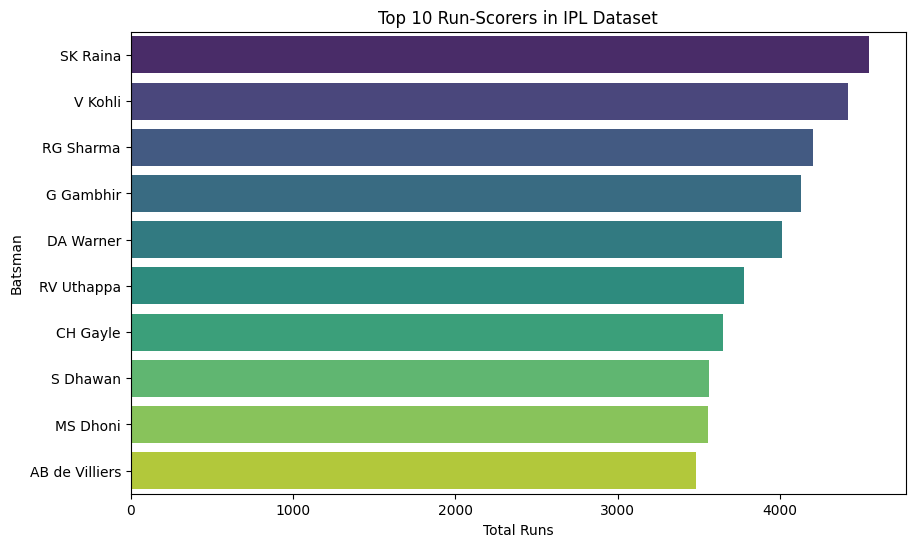

,Batsman,Total Runs
0,SK Raina,4548
1,V Kohli,4423
2,RG Sharma,4207
3,G Gambhir,4132
4,DA Warner,4014
5,RV Uthappa,3778
6,CH Gayle,3651
7,S Dhawan,3561
8,MS Dhoni,3560
9,AB de Villiers,3486


In [8]:
top_10_run_scorers = (deliveries_df.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(10).reset_index())
top_10_run_scorers.columns = ["Batsman", "Total Runs"]
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_run_scorers,y="Batsman",x="Total Runs",hue="Batsman",palette="viridis",legend=False)
plt.title("Top 10 Run-Scorers in IPL Dataset")
plt.xlabel("Total Runs")
plt.ylabel("Batsman")
plt.show()
top_10_run_scorers

### Interpretation

The chart shows the leading batsmen by total runs across all seasons in the dataset.  
Players at the top have scored consistently over multiple seasons, which indicates both performance and longevity.  
Such players are key assets because they provide stability to the batting order.

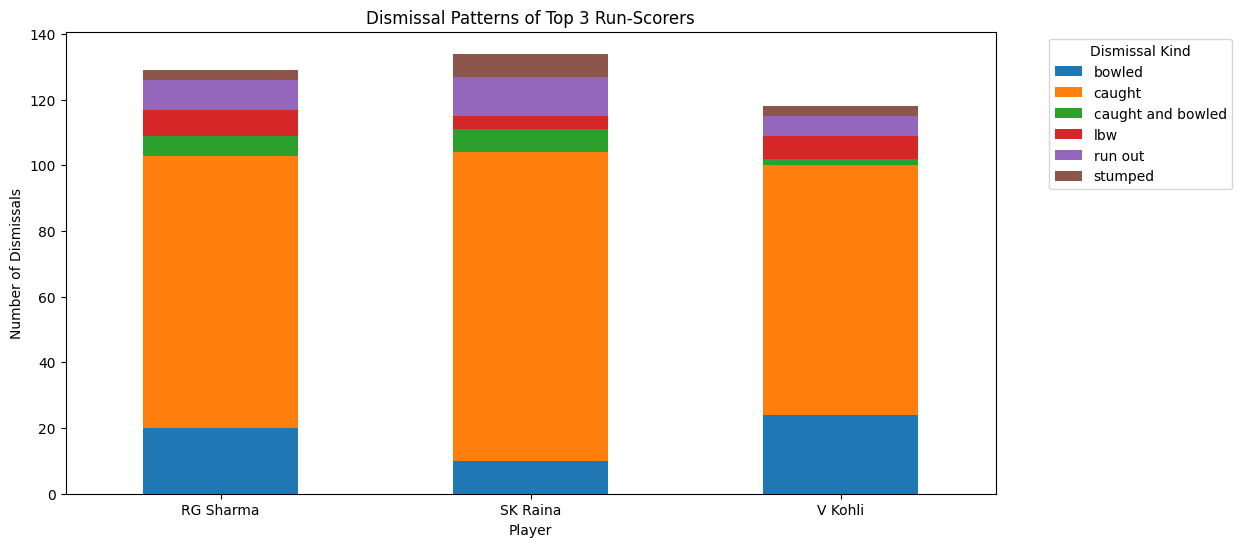

dismissal_kind,bowled,caught,caught and bowled,lbw,run out,stumped
player_dismissed,,,,,,
RG Sharma,20,83,6,8,9,3
SK Raina,10,94,7,4,12,7
V Kohli,24,76,2,7,6,3


In [9]:
top_3_batsmen = top_10_run_scorers["Batsman"].head(3).tolist()
dismissal_pattern = (deliveries_df[deliveries_df["player_dismissed"].isin(top_3_batsmen)].groupby(["player_dismissed", "dismissal_kind"]).size().reset_index(name="count"))
dismissal_pivot = dismissal_pattern.pivot(index="player_dismissed",columns="dismissal_kind",values="count").fillna(0)
dismissal_pivot.plot(kind="bar",stacked=True,figsize=(12, 6))
plt.title("Dismissal Patterns of Top 3 Run-Scorers")
plt.xlabel("Player")
plt.ylabel("Number of Dismissals")
plt.legend(title="Dismissal Kind", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.show()
dismissal_pivot

### Interpretation

For the top 3 run-scorers, caught dismissals are the most common dismissal type.  
This suggests that attacking shots and aerial strokes create a major risk even for elite batsmen.  
Teams can use this information to set attacking field placements and plan bowling strategies against these players.

## 7. Seasonal Batting Trends



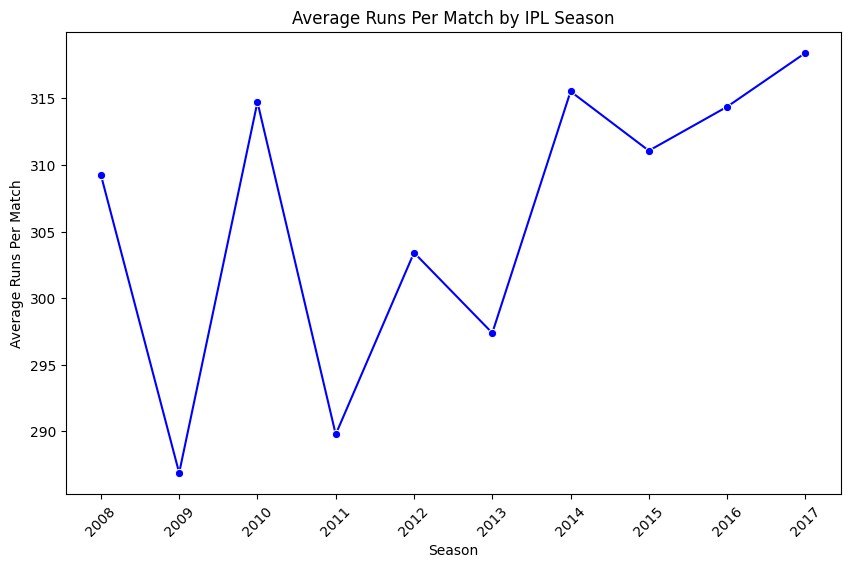

,season,total_runs,total_matches,avg_runs_per_match
0,2008,17937,58,309.26
1,2009,16353,57,286.89
2,2010,18883,60,314.72
3,2011,21154,73,289.78
4,2012,22453,74,303.42
5,2013,22602,76,297.39
6,2014,18931,60,315.52
7,2015,18353,59,311.07
8,2016,18862,60,314.37
9,2017,18786,59,318.41


In [10]:
match_runs = (deliveries_df.groupby("match_id")["total_runs"].sum().reset_index(name="match_total_runs"))
seasonal_runs = match_runs.merge(matches_df[["id", "season"]],left_on="match_id",right_on="id",how="left")

average_runs_per_match = (seasonal_runs.groupby("season").agg(total_runs=("match_total_runs", "sum"),total_matches=("match_id", "nunique")).reset_index())
average_runs_per_match["avg_runs_per_match"] = np.round(average_runs_per_match["total_runs"] / average_runs_per_match["total_matches"],2)

plt.figure(figsize=(10, 6))
sns.lineplot(data=average_runs_per_match,x="season",y="avg_runs_per_match",marker="o",color="blue")

plt.title("Average Runs Per Match by IPL Season")
plt.xlabel("Season")
plt.ylabel("Average Runs Per Match")
plt.xticks(average_runs_per_match["season"], rotation=45)
plt.show()

average_runs_per_match

### Interpretation

The average runs per match vary by season, showing that scoring conditions were not the same every year.  
Some seasons show clear dips, while later seasons show a slightly higher scoring pattern.  
This may be due to batting improvements, venue conditions, rule changes, or team strategies.

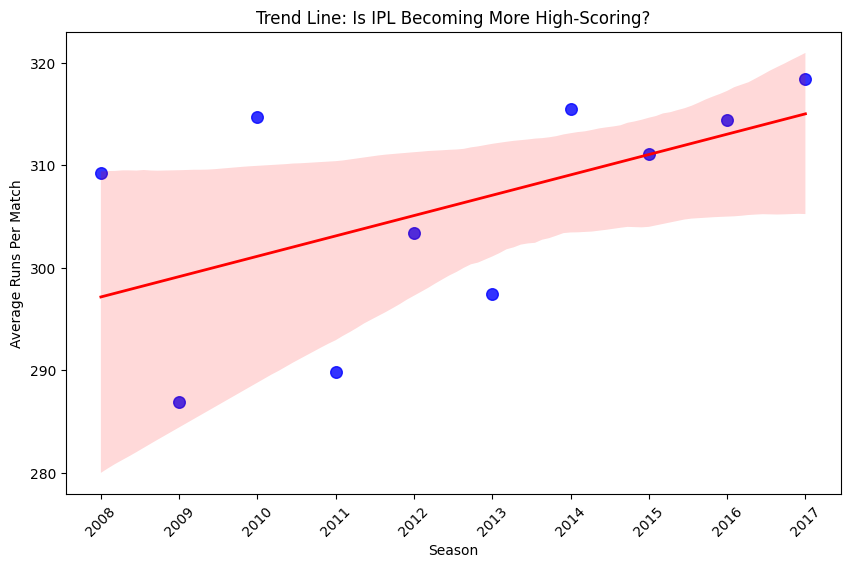

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(data=average_runs_per_match,x="season",y="avg_runs_per_match",scatter_kws={"s": 70, "color": "blue"},line_kws={"linewidth": 2, "color": "red"})
plt.title("Trend Line: Is IPL Becoming More High-Scoring?")
plt.xlabel("Season")
plt.ylabel("Average Runs Per Match")
plt.xticks(average_runs_per_match["season"], rotation=45)
plt.show()

### Interpretation

The regression line gives a simple view of the overall scoring trend across seasons.  
In this dataset, the scoring trend appears slightly upward, especially when comparing the lower-scoring seasons with later seasons.  
This suggests that IPL matches became somewhat more high-scoring over time, but the trend is not perfectly smooth.

## 8. Match Outcome & Venue Analysis



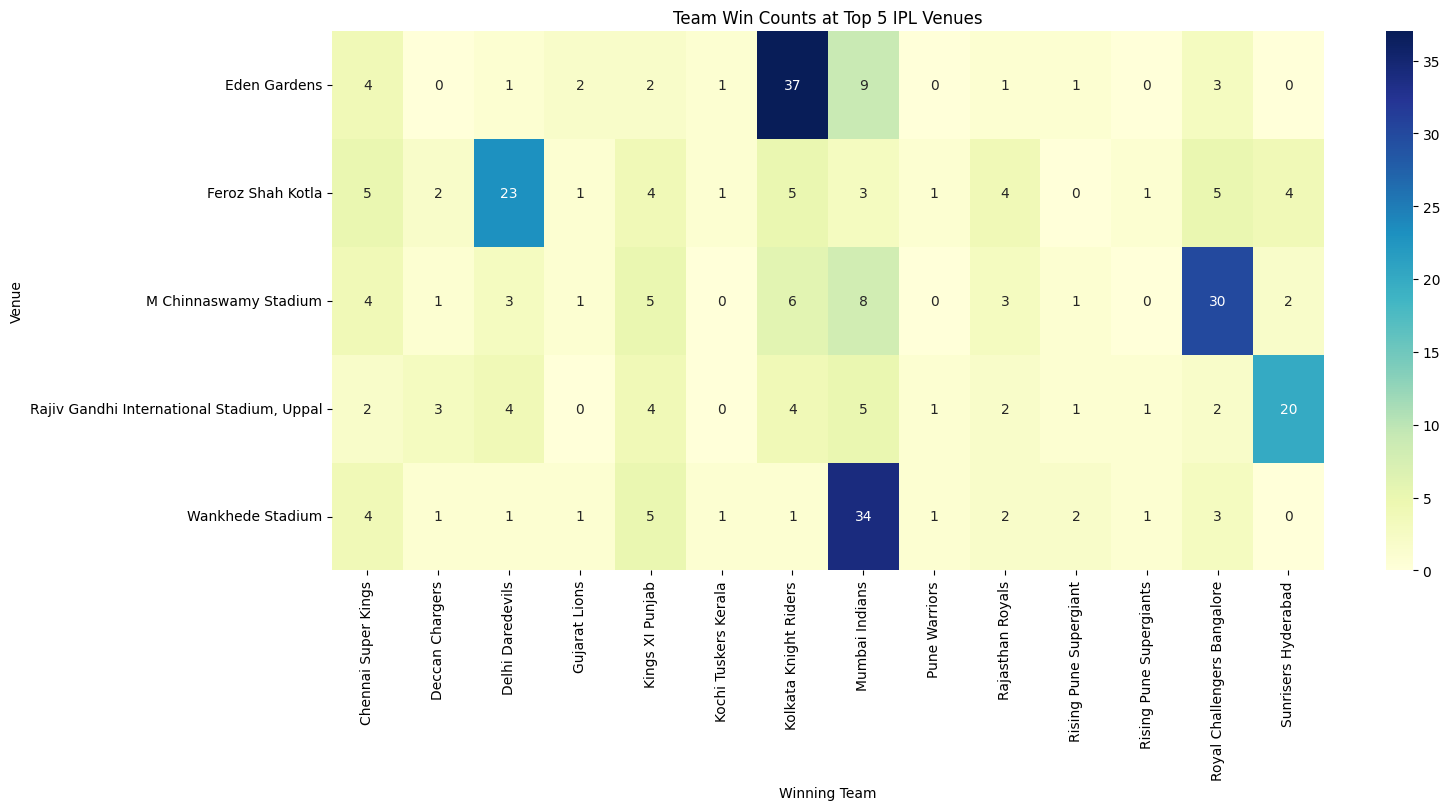

,venue,winner,win_count
0,Eden Gardens,Kolkata Knight Riders,37
1,Feroz Shah Kotla,Delhi Daredevils,23
2,M Chinnaswamy Stadium,Royal Challengers Bangalore,30
3,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,20
4,Wankhede Stadium,Mumbai Indians,34


In [12]:
top_5_venues = matches_df["venue"].value_counts().head(5).index.tolist()
venue_wins = (matches_df[matches_df["venue"].isin(top_5_venues)].groupby(["venue", "winner"]).size().reset_index(name="win_count"))
venue_heatmap = venue_wins.pivot(index="venue",columns="winner",values="win_count").fillna(0)
plt.figure(figsize=(16, 7))
sns.heatmap(venue_heatmap,annot=True,fmt=".0f",cmap="YlGnBu")
plt.title("Team Win Counts at Top 5 IPL Venues")
plt.xlabel("Winning Team")
plt.ylabel("Venue")
plt.show()
top_winner_by_venue = (venue_wins.sort_values(["venue", "win_count"], ascending=[True, False]).groupby("venue").head(1).reset_index(drop=True))
top_winner_by_venue

### Interpretation

The heatmap shows that some teams have very high win counts at specific venues.  
For example, Kolkata Knight Riders at Eden Gardens, Mumbai Indians at Wankhede Stadium, and Royal Challengers Bangalore at M Chinnaswamy Stadium show strong venue dominance.  
This suggests possible home advantage, although the dataset does not directly label home and away teams.

## 9. Death Over Performance



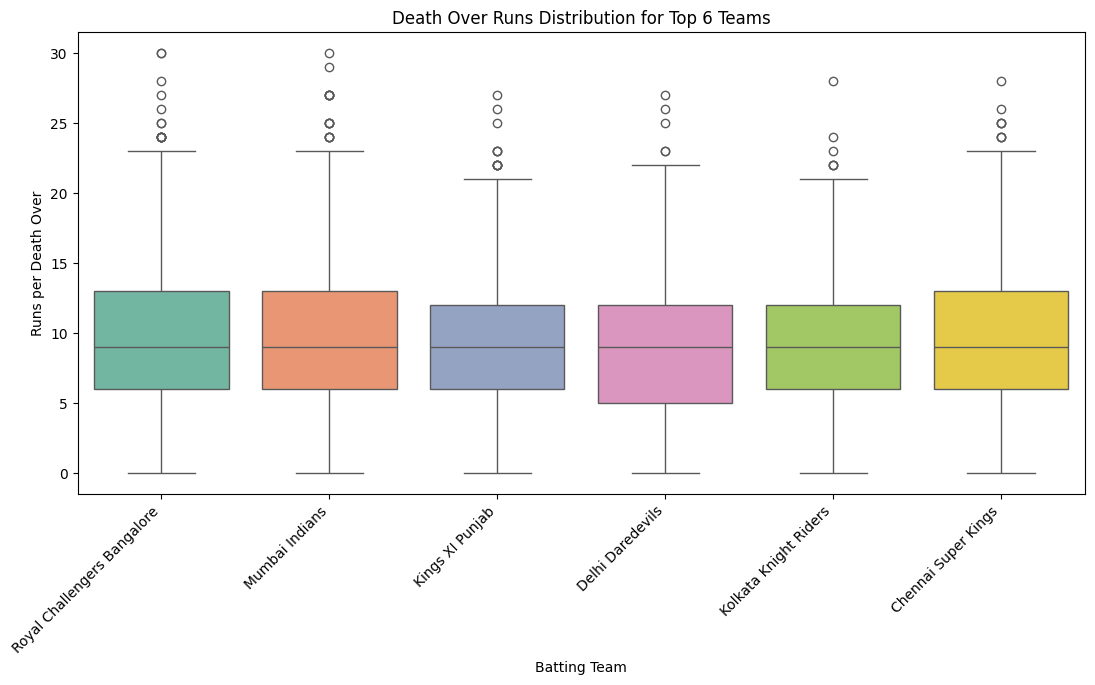

,median,mean,std
batting_team,,,
Royal Challengers Bangalore,9.0,10.24,5.50
Mumbai Indians,9.0,9.97,5.26
Chennai Super Kings,9.0,9.91,4.98
Kings XI Punjab,9.0,9.21,4.84
Kolkata Knight Riders,9.0,9.17,4.59
Delhi Daredevils,9.0,9.12,4.92


In [13]:
death_overs = deliveries_df[(over_arr >= 16) &(over_arr <= 20)
].copy()

top_6_death_teams = (death_overs.groupby("batting_team")["total_runs"].sum().sort_values(ascending=False).head(6).index.tolist()
)

death_over_runs = (death_overs[death_overs["batting_team"].isin(top_6_death_teams)].groupby(["match_id", "inning", "batting_team", "over"])["total_runs"].sum().reset_index()
)

plt.figure(figsize=(13, 6))
sns.boxplot(data=death_over_runs,x="batting_team",y="total_runs",hue="batting_team",palette="Set2",legend=False
)

plt.title("Death Over Runs Distribution for Top 6 Teams")
plt.xlabel("Batting Team")
plt.ylabel("Runs per Death Over")
plt.xticks(rotation=45, ha="right")
plt.show()

death_over_team_stats = (
    death_over_runs.groupby("batting_team")["total_runs"]
    .agg(["median", "mean", "std"])
    .round(2)
    .sort_values("mean", ascending=False)
)

death_over_team_stats

### Interpretation

The death-over box plot compares both consistency and explosiveness.  
A higher median shows consistent scoring, while a larger spread indicates explosive but less predictable scoring.  
In this dataset, Royal Challengers Bangalore and Mumbai Indians show strong death-over scoring, with RCB appearing especially explosive due to a high mean and high variation.

# Part C – Storytelling & Final Report

## Executive Summary

The most important insight from this IPL analysis is that **chasing/field-first strategy often performs better than batting first after winning the toss**, but the advantage changes across seasons.  
The data also shows that top teams and players are successful because of consistency across seasons, venue strength, and strong death-over performance.

## Key Insights

1. **Toss decision matters, but not always consistently.**  
   Teams choosing to field after winning the toss had a better overall win percentage than teams choosing to bat first. However, season-wise performance shows that this advantage changes depending on conditions.

2. **Top batsmen provide long-term batting stability.**  
   SK Raina, Virat Kohli, Rohit Sharma, Gautam Gambhir, and David Warner are among the top run-scorers. Their consistent scoring over multiple seasons makes them important players for their teams.

3. **Caught dismissals dominate for top run-scorers.**  
   The top 3 run-scorers were dismissed most often by catches. This suggests that even strong batsmen are vulnerable when forced into aerial shots.

4. **IPL scoring shows a slightly upward trend over time.**  
   Average runs per match increased in some later seasons, indicating that batting strategies and scoring rates may have improved.

5. **Venue dominance suggests home advantage.**  
   Kolkata Knight Riders at Eden Gardens, Mumbai Indians at Wankhede Stadium, and Royal Challengers Bangalore at M Chinnaswamy Stadium show strong venue performance.

## Recommendation for Team Strategy

A captain or coach should **prefer fielding first after winning the toss when conditions support chasing**.  
This strategy gives the chasing team a clear target and allows better planning of batting resources.  
Also, teams should select death-over specialists because strong scoring in overs 16–20 can change the final match result.

## Self-Reflection / Limitation

One limitation of this dataset is that it does not include detailed context such as pitch type, weather, dew factor, boundary size, player fitness, and home/away labels.  
These extra features would allow deeper analysis of toss decisions, venue advantage, and team strategy.